In [24]:
import sys
from pathlib import Path

def is_google_colab() -> bool:
    if "google.colab" in str(get_ipython()):
        return True
    return False

def clone_repository() -> None:
    !git clone https://github.com/featurestorebook/mlfs-book.git
    %cd mlfs-book

def install_dependencies() -> None:
    !pip install --upgrade uv
    !uv pip install --all-extras --system --requirement pyproject.toml

if is_google_colab():
    clone_repository()
    install_dependencies()
    root_dir = str(Path().absolute())
    print("Google Colab environment")
else:
    root_dir = Path().absolute()
    # Strip ~/notebooks/ccfraud from PYTHON_PATH if notebook started in one of these subdirectories
    if root_dir.parts[-1:] == ('airquality',):
        root_dir = Path(*root_dir.parts[:-1])
    if root_dir.parts[-1:] == ('notebooks',):
        root_dir = Path(*root_dir.parts[:-1])
    root_dir = str(root_dir) 
    print("Local environment")

# Add the root directory to the `PYTHONPATH` to use the `recsys` Python module from the notebook.
if root_dir not in sys.path:
    sys.path.append(root_dir)
print(f"Added the following directory to the PYTHONPATH: {root_dir}")
    
# Set the environment variables from the file <root_dir>/.env
from mlfs import config
settings = config.HopsworksSettings(_env_file=f"{root_dir}/.env")

Local environment
Added the following directory to the PYTHONPATH: /Users/edvinramstrom/Documents/KTH/ID2223 Scalable/mlfs-book
HopsworksSettings initialized!


# <span style="font-width:bold; font-size: 3rem; color:#333;">Training Pipeline</span>

## 🗒️ This notebook is divided into the following sections:

1. Select features for the model and create a Feature View with the selected features
2. Create training data using the feature view
3. Train model
4. Evaluate model performance
5. Save model to model registry

### <span style='color:#ff5f27'> 📝 Imports

In [25]:
import os
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.metrics import mean_squared_error, r2_score
import hopsworks
from mlfs.airquality import util
import json

import warnings
warnings.filterwarnings("ignore")

### <span style='color:#ff5f27'> 🎯 Sensor Configuration</span>

**Change the sensor street name below to select which sensor to train a model for:**

In [26]:
# === SENSOR SELECTION - SET THIS PARAMETER ===
# This can be set via papermill: papermill input.ipynb output.ipynb -p SENSOR_STREET "arnulf-klett-platz"
SENSOR_STREET = "am-neckartor"  # Options: "arnulf-klett-platz", "am-neckartor"

print(f"Training model for sensor: {SENSOR_STREET}")

Training model for sensor: am-neckartor


## <span style="color:#ff5f27;"> 📡 Connect to Hopsworks Feature Store </span>

In [27]:
# Check if HOPSWORKS_API_KEY env variable is set or if it is set in ~/.env
if settings.HOPSWORKS_API_KEY is not None:
    api_key = settings.HOPSWORKS_API_KEY.get_secret_value()
    os.environ['HOPSWORKS_API_KEY'] = api_key
project = hopsworks.login(engine="python")
fs = project.get_feature_store() 

secrets = hopsworks.get_secrets_api()

# Load sensor-specific configuration from Hopsworks secret
secret_name = f"SENSOR_LOCATION_JSON_{SENSOR_STREET.upper().replace('-', '_')}"
location_str = secrets.get_secret(secret_name).value
location = json.loads(location_str)

country=location['country']
city=location['city']
street=location['street']

print(f"Loaded configuration for sensor: {street}")

2025-11-18 17:04:44,562 INFO: Closing external client and cleaning up certificates.
Connection closed.
2025-11-18 17:04:44,565 INFO: Initializing external client
2025-11-18 17:04:44,565 INFO: Base URL: https://c.app.hopsworks.ai:443
Connection closed.
2025-11-18 17:04:44,565 INFO: Initializing external client
2025-11-18 17:04:44,565 INFO: Base URL: https://c.app.hopsworks.ai:443


2025-11-18 17:04:45,984 INFO: Python Engine initialized.

Logged in to project, explore it here https://c.app.hopsworks.ai:443/p/1298581

Logged in to project, explore it here https://c.app.hopsworks.ai:443/p/1298581
Loaded configuration for sensor: am-neckartor
Loaded configuration for sensor: am-neckartor


In [28]:
# Retrieve feature groups
air_quality_fg = fs.get_feature_group(
    name='air_quality',
    version=3,
)
weather_fg = fs.get_feature_group(
    name='weather',
    version=2,
)

--- 

## <span style="color:#ff5f27;"> 🖍 Feature View Creation and Retrieving </span>

In [29]:
# Select features for training data - including lagged PM2.5 features
# Filter by the specific sensor street
selected_features = air_quality_fg.select(['pm25', 'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'date', 'day_of_week']).filter(air_quality_fg.street == street).join(weather_fg.select_features(), on=['city'])

print(f"Training data filtered for street: {street}")

2025-11-18 17:04:48,194 INFO: Using ['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'wind_direction_10m_dominant', 'relative_humidity_2m_mean', 'surface_pressure_mean'] from feature group `weather` as features for the query. To include primary key and event time use `select_all`.
Training data filtered for street: am-neckartor
Training data filtered for street: am-neckartor


### Feature Views

`Feature Views` are selections of features from different **Feature Groups** that make up the input and output API (or schema) for a model. A **Feature Views** can create **Training Data** and also be used in Inference to retrieve inference data.

The Feature Views allows a schema in form of a query with filters, defining a model target feature/label and additional transformation functions (declarative feature encoding).

In order to create Feature View we can use `FeatureStore.get_or_create_feature_view()` method.

You can specify the following parameters:

- `name` - name of a feature group.

- `version` - version of a feature group.

- `labels`- our target variable.

- `transformation_functions` - declarative feature encoding (not used here)

- `query` - selected features/labels for the model 

In [30]:
feature_view = fs.get_or_create_feature_view(
    name='air_quality_fv',
    description="weather features with air quality as the target, including lagged PM2.5 values",
    version=3,
    labels=['pm25'],
    query=selected_features,
)

## <span style="color:#ff5f27;">🪝 Split the training data into train/test data sets </span>

We use a time-series split here, with training data before this date `start_date_test_data` and test data after this date

In [31]:
start_date_test_data = "2025-05-01"
# Convert string to datetime object
test_start = datetime.strptime(start_date_test_data, "%Y-%m-%d")

In [32]:
X_train, X_test, y_train, y_test = feature_view.train_test_split(
    test_start=test_start
)

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.39s) 
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.39s) 


In [33]:
X_train

,pm25_lag1,pm25_lag2,pm25_lag3,date,day_of_week,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,relative_humidity_2m_mean,surface_pressure_mean
0,58.0,64.0,55.0,2018-11-06 00:00:00+00:00,1,9.953751,0.0,9.693295,179.999985,83.310295,979.104004
1,58.0,63.0,53.0,2018-11-06 00:00:00+00:00,1,9.953751,0.0,9.693295,179.999985,83.310295,979.104004
2,66.0,58.0,64.0,2018-11-07 00:00:00+00:00,2,9.826668,0.1,7.771331,214.380371,85.039375,983.193665
3,68.0,58.0,63.0,2018-11-07 00:00:00+00:00,2,9.826668,0.1,7.771331,214.380371,85.039375,983.193665
4,66.0,66.0,58.0,2018-11-08 00:00:00+00:00,3,9.782917,0.9,8.311245,83.853523,89.788780,991.033447
...,...,...,...,...,...,...,...,...,...,...,...
4676,40.0,42.0,18.0,2025-04-28 00:00:00+00:00,0,13.828750,0.0,12.646200,3.284861,67.577576,995.394714
4677,34.0,47.0,49.0,2025-04-29 00:00:00+00:00,1,15.257915,0.0,11.792404,4.848209,69.903091,994.678223
4678,26.0,40.0,42.0,2025-04-29 00:00:00+00:00,1,15.257915,0.0,11.792404,4.848209,69.903091,994.678223
4679,43.0,34.0,47.0,2025-04-30 00:00:00+00:00,2,16.668333,0.0,10.662626,24.804041,66.296928,992.838440


In [34]:
X_features = X_train.drop(columns=['date'])
X_test_features = X_test.drop(columns=['date'])

In [35]:
y_train

,pm25
0,66.0
1,68.0
2,66.0
3,69.0
4,54.0
...,...
4676,26.0
4677,43.0
4678,34.0
4679,53.0


The `Feature View` is now saved in Hopsworks and you can retrieve it using `FeatureStore.get_feature_view(name='...', version=1)`.

In [36]:
import plotly.express as px

X_train_with_date = X_train.copy()
feature_cols = [col for col in X_train_with_date.columns if col != 'date']

fig = px.line(X_train_with_date, x='date', y=feature_cols, title='All Features Over Time')
# fig.show()

---

## <span style="color:#ff5f27;">🧬 Modeling</span>

We will train a regression model to predict pm25 using our 4 features (wind_speed, wind_dir, temp, precipitation)

In [37]:
# Creating an instance of the XGBoost Regressor
xgb_regressor = XGBRegressor()

# Fitting the XGBoost Regressor to the training data
xgb_regressor.fit(X_features, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [38]:
# Predicting target values on the test set
y_pred_iterative = []

# Sort test data by date
X_test_sorted = X_test.sort_values('date').reset_index(drop=True)
X_test_features_sorted = X_test_sorted.drop(columns=['date']).copy()

for i in range(len(X_test_sorted)):
    # Make prediction for current day
    current_features = X_test_features_sorted.iloc[[i]].copy()
    pred = xgb_regressor.predict(current_features)[0]
    y_pred_iterative.append(pred)
    
    # Debug print
    # print(f"Day {i} Predicted PM2.5 = {pred:.2f}, Lags used: [{current_features['pm25_lag1'].values[0]:.2f}, {current_features['pm25_lag2'].values[0]:.2f}, {current_features['pm25_lag3'].values[0]:.2f}]")

    
    # Update lagged features for subsequent predictions
    # The next day's lag1 becomes today's prediction
    if i + 1 < len(X_test_sorted):
        X_test_features_sorted.loc[i + 1, 'pm25_lag1'] = pred
        # Shift other lags
        if i + 2 < len(X_test_sorted):
            X_test_features_sorted.loc[i + 2, 'pm25_lag2'] = pred
        if i + 3 < len(X_test_sorted):
            X_test_features_sorted.loc[i + 3, 'pm25_lag3'] = pred

y_pred_iterative = pd.Series(y_pred_iterative, index=X_test_sorted.index)
y_pred = y_pred_iterative.copy()

# Calculating Mean Squared Error (MSE) using sklearn
mse = mean_squared_error(y_test.iloc[:,0], y_pred)
print("MSE:", mse)

# Calculating R squared using sklearn
r2 = r2_score(y_test.iloc[:,0], y_pred)
print("R squared:", r2)

MSE: 204.83707
R squared: 0.013215097187521785


In [39]:

df = y_test
df['predicted_pm25'] = y_pred.values

In [40]:
df['date'] = X_test['date']
df = df.sort_values(by=['date'])
df

,pm25,predicted_pm25,date
4681,55.0,53.499969,2025-05-01 00:00:00+00:00
4682,48.0,52.959606,2025-05-01 00:00:00+00:00
4683,56.0,45.162697,2025-05-02 00:00:00+00:00
4684,45.0,40.943485,2025-05-02 00:00:00+00:00
4685,58.0,42.045677,2025-05-03 00:00:00+00:00
...,...,...,...
5080,53.0,42.076462,2025-11-16 00:00:00+00:00
5081,29.0,34.605312,2025-11-17 00:00:00+00:00
5082,28.0,32.306839,2025-11-17 00:00:00+00:00
5083,17.0,49.654274,2025-11-18 00:00:00+00:00


In [41]:
# Creating a directory for the model artifacts if it doesn't exist
model_dir = "air_quality_model"
if not os.path.exists(model_dir):
    os.mkdir(model_dir)
images_dir = model_dir + "/images"
if not os.path.exists(images_dir):
    os.mkdir(images_dir)

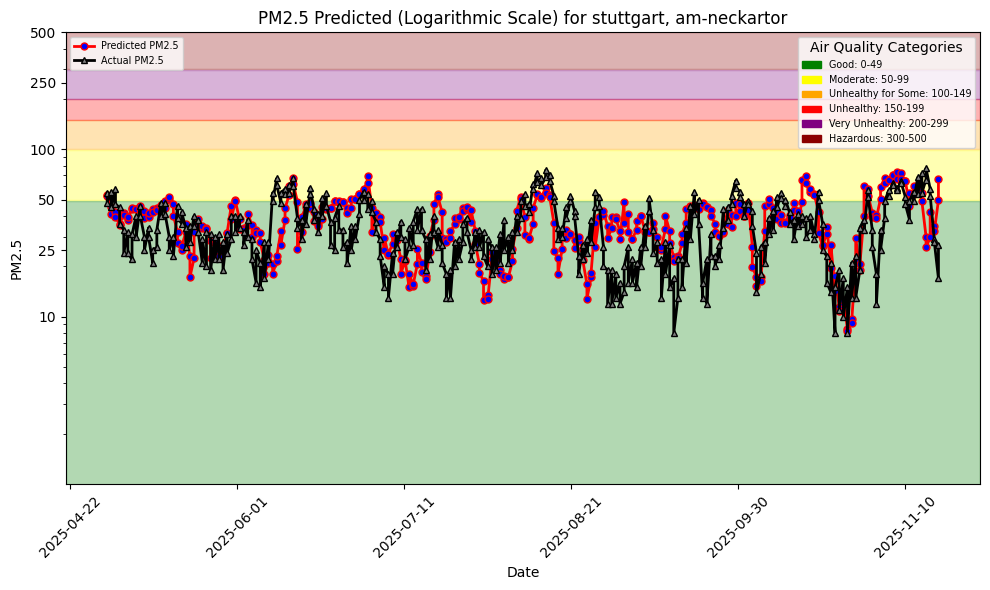

In [42]:
file_path = images_dir + "/pm25_hindcast.png"
plt = util.plot_air_quality_forecast(city, street, df, file_path, hindcast=True) 
plt.show()

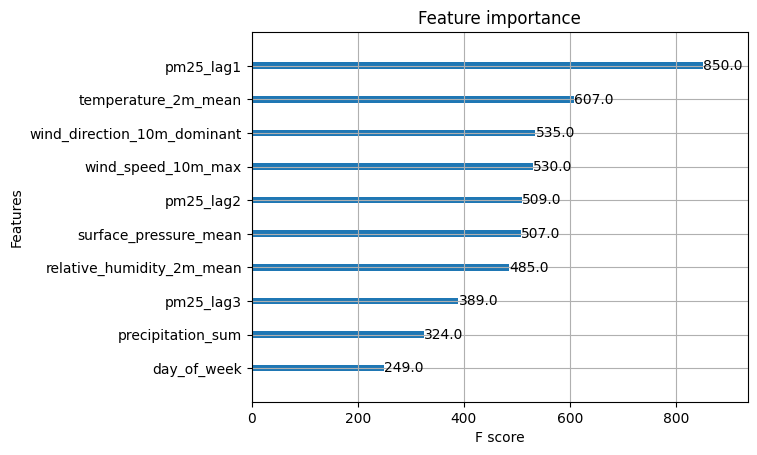

In [43]:
# Plotting feature importances using the plot_importance function from XGBoost
plot_importance(xgb_regressor)
feature_importance_path = images_dir + "/feature_importance.png"
plt.savefig(feature_importance_path)
plt.show()

---

## <span style='color:#ff5f27'>🗄 Model Registry</span>

One of the features in Hopsworks is the model registry. This is where you can store different versions of models and compare their performance. Models from the registry can then be served as API endpoints.

In [44]:
# Saving the XGBoost regressor object as a json file in the model directory
xgb_regressor.save_model(model_dir + "/model.json")

In [45]:
res_dict = { 
        "MSE": str(mse),
        "R squared": str(r2),
    }

In [46]:
mr = project.get_model_registry()

# Creating a Python model in the model registry with sensor-specific name
model_name = f"air_quality_xgboost_model_{street.replace('-', '_')}"
print(f"Creating model: {model_name}")

aq_model = mr.python.create_model(
    name=model_name, 
    metrics= res_dict,
    feature_view=feature_view,
    description=f"Air Quality (PM2.5) predictor for {city} - {street}",
)

# Saving the model artifacts to the 'air_quality_model' directory in the model registry
aq_model.save(model_dir)

Creating model: air_quality_xgboost_model_am_neckartor


  0%|          | 0/6 [00:00<?, ?it/s]

Uploading /Users/edvinramstrom/Documents/KTH/ID2223 Scalable/mlfs-book/notebooks/airquality/air_quality_model/…

Uploading /Users/edvinramstrom/Documents/KTH/ID2223 Scalable/mlfs-book/notebooks/airquality/air_quality_model/…

Uploading /Users/edvinramstrom/Documents/KTH/ID2223 Scalable/mlfs-book/notebooks/airquality/air_quality_model/…

Uploading /Users/edvinramstrom/Documents/KTH/ID2223 Scalable/mlfs-book/notebooks/airquality/model_schema.json:…

Model created, explore it at https://c.app.hopsworks.ai:443/p/1298581/models/air_quality_xgboost_model_am_neckartor/1


Model(name: 'air_quality_xgboost_model_am_neckartor', version: 1)

---
## <span style="color:#ff5f27;">⏭️ **Next:** Part 04: Batch Inference</span>

In the following notebook you will use your model for Batch Inference.
